In [25]:
import numpy as np
from matplotlib import pyplot as plt

import astropy.units as u
import scipy.stats as sps

from config.plotting import set_plotting_defaults, save_figure
from spectrum.Xrism_area_energy_dependence import XrismArea

plt.ioff()  # turn off interactive mode

In [26]:
def test_a_dist(xy, yx, num_tot, ax=plt.gca()):
    xrism_area = XrismArea()
    ans = xrism_area.count(xy, yx) / num_tot
    x1, y1 = xrism_area.get(xy, yx)
    print(f"grid: {ans}")

    ax.scatter(xy, yx, s=1)
    ax.scatter(x1, y1, s=1)
    return

In [27]:
def test_xrism_area_grid(x_size, y_size, num_x=40, num_y=100, ax=plt.gca()):
    x = np.linspace(-x_size, x_size, num_x)
    y = np.linspace(-y_size, y_size, num_y)
    xy, yx = np.meshgrid(x, y, indexing='xy')

    test_a_dist(xy, yx, num_x * num_y, ax=ax)
    return

In [28]:
def test_uniform(x_size, y_size, num_tot: int = 4000, ax=plt.gca()):
    rnd = sps.uniform(loc=[0.0 - x_size.value, 0.0 - y_size.value],
                      scale=[2 * x_size.value, 2 * y_size.value])

    rnd_vals = rnd.rvs(size=[num_tot, 2]) * u.pc
    rnd_x, rnd_y = rnd_vals[:, 0], rnd_vals[:, 1]

    test_a_dist(rnd_x, rnd_y, num_tot, ax=ax)
    return

In [29]:
def test_gaussian(x_size, y_size, num_tot: int = 4000, ax=plt.gca()):
    rnd = sps.norm(loc=[0.0, 0.0], scale=[x_size.value, y_size.value])

    rnd_vals = rnd.rvs(size=[num_tot, 2]) * u.pc

    rnd_x, rnd_y = rnd_vals[:, 0], rnd_vals[:, 1]

    test_a_dist(rnd_x, rnd_y, num_tot, ax=ax)
    return

grid: 0.1525
grid: 0.155
grid: 0.26675


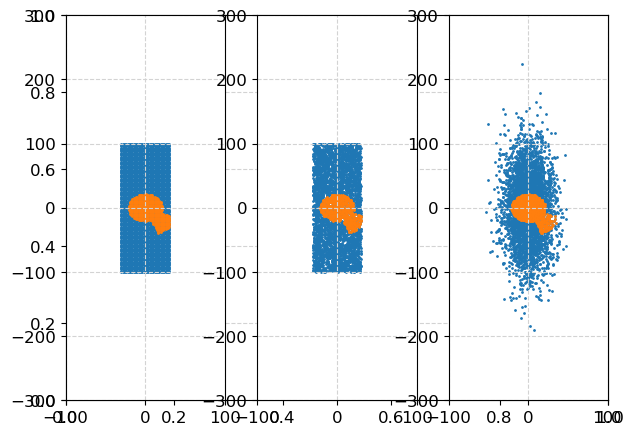

In [30]:
ax1 = plt.subplot(1, 3, 1)
test_xrism_area_grid(30 * u.pc, 100 * u.pc, ax=ax1)
ax1.set_xlim(-100, 100)
ax1.set_ylim(-300, 300)
ax2 = plt.subplot(1, 3, 2)
test_uniform(30 * u.pc, 100 * u.pc, ax=ax2)
ax2.set_xlim(-100, 100)
ax2.set_ylim(-300, 300)
ax3 = plt.subplot(1, 3, 3)
test_gaussian(30 * u.pc/2, 100 * u.pc/2, ax=ax3)
ax3.set_xlim(-100, 100)
ax3.set_ylim(-300, 300)
plt.show()

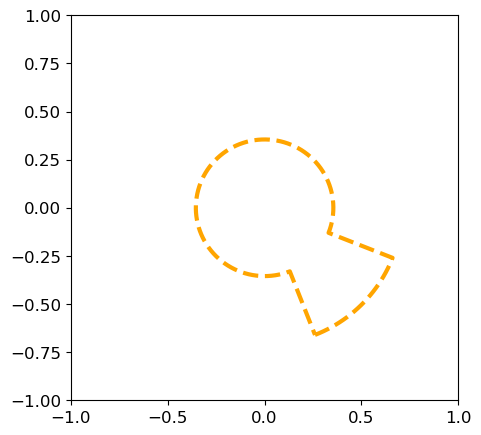

In [33]:
xrismarea = XrismArea()
x, y = xrismarea.get_contours()

plt.figure(figsize=(5, 5))
plt.plot(1/60 * x, 1/60 * y, color='orange', linestyle='dashed', linewidth=3)
plt.ylim(-1.0, 1.0)
plt.xlim(-1.0, 1.0)
plt.grid(False)
save_figure("XRISM_area_contour")
plt.show()